<a href="https://colab.research.google.com/github/betulbilhan2/LLM-Augmentation-Fidelity/blob/main/NB08_Evaluation_and_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 08: Final Test & Metrics (Sanity Check & Aggregated Confusion Matrix)

**Objectives:**
1. **80 Run Sanity Check:** Verify if all 80 runs (`2 Resource Levels * 4 Scenarios * 10 Seeds`) are successfully completed and recorded in the `07_results` directory.
2. **Format Adjustments:** Rename class-based F1 metrics (`f1_class_0`, `f1_class_1`, `f1_class_2`) to `Negative, Neutral, Positive` and export the data in "long format" for statistical analysis in NB09.
3. **Aggregated Confusion Matrix:** Investigate the pilot anomaly (Neutral class bottleneck) by plotting the **sum/average of 10 seeds** for the same scenario and resource level, rather than relying on a single seed.

*Note: Test predictions and data leakage prevention were already handled during the `trainer.predict()` phase in NB07. This notebook analyzes the generated results in a disk-friendly manner without loading the models.*

In [ ]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/tr_augmentation_project'
    IN_COLAB = True
except:
    BASE_DIR = 'C:/Users/btlbi/OneDrive/Masaustu/TR Veri arttirimi'
    IN_COLAB = False

RESULTS_DIR = os.path.join(BASE_DIR, '07_results')
EVAL_DIR = os.path.join(BASE_DIR, '08_evaluation')
os.makedirs(EVAL_DIR, exist_ok=True)
print("Directories are ready.")


Mounted at /content/drive
Directories are ready.


## 1. Sanity Check (Are All 80 Runs Completed?)

In [ ]:
json_files = glob.glob(os.path.join(RESULTS_DIR, "*.json"))
print(f"Found JSON records: {len(json_files)} / 80")

levels = ['low', 'normal']
scenarios = ['E0', 'E1', 'E2', 'E3']
seeds = list(range(10))

missing = []
for level in levels:
    for scen in scenarios:
        for seed in seeds:
            expected_name = f"{level}_{scen}_seed{seed}.json"
            if not os.path.exists(os.path.join(RESULTS_DIR, expected_name)):
                missing.append(expected_name)

if missing:
    print(f"\n[WARNING] There are {len(missing)} missing runs:")
    print(missing[:10], "..." if len(missing)>10 else "")
else:
    print("\n[SUCCESS] All 80 runs have been successfully recorded!")
# Karantina İspatı (Leakage Check)
import glob
train_files = glob.glob(os.path.join(BASE_DIR, "05_balanced", "*", "*", "*.csv"))
for t_file in train_files:
    assert "test.csv" not in t_file, f"Sızıntı Tespiti: Test verisi eğitim klasöründe bulundu! -> {t_file}"
print("✅ Test setinin izolasyonu sağlandı (No Leakage).")

Found JSON records: 80 / 80

[SUCCESS] All 80 runs have been successfully recorded!
✅ Test setinin izolasyonu sağlandı (No Leakage).


## 2. Loading Metrics and Preparing Long Format for NB09

In [ ]:
data_rows = []
for file_path in json_files:
    with open(file_path, 'r', encoding='utf-8') as f:
        run_data = json.load(f)
        metrics = run_data.get('test_results', {})

        data_rows.append({
            'resource_level': run_data['level'],
            'scenario': run_data['scenario'],
            'seed': run_data['seed'],
            'train_time_sec': run_data.get('train_time_sec', 0),
            'macro_f1': metrics.get('test_macro_f1', 0),
            'f1_negative': metrics.get('test_f1_class_0', 0),
            'f1_neutral': metrics.get('test_f1_class_1', 0),
            'f1_positive': metrics.get('test_f1_class_2', 0),
        })

df_results = pd.DataFrame(data_rows)
df_results = df_results.sort_values(by=['resource_level', 'scenario', 'seed']).reset_index(drop=True)

display(df_results.head())

long_format_path = os.path.join(EVAL_DIR, 'all_results_long_format.csv')
df_results.to_csv(long_format_path, index=False)
print(f"\nResults saved to: {long_format_path}")


,resource_level,scenario,seed,train_time_sec,macro_f1,f1_negative,f1_neutral,f1_positive
0,low,E0,0,299.111069,0.525804,0.270468,0.746434,0.560511
1,low,E0,1,523.016380,0.615918,0.376279,0.761298,0.710176
2,low,E0,2,351.816885,0.499033,0.195929,0.723394,0.577775
3,low,E0,3,348.005420,0.535014,0.165700,0.742866,0.696475
4,low,E0,4,265.881076,0.495876,0.063855,0.750088,0.673685



Results saved to: /content/drive/MyDrive/tr_augmentation_project/08_evaluation/all_results_long_format.csv


## 3. Average F1 Tables (Summary for the Paper)

In [ ]:
summary = df_results.groupby(['resource_level', 'scenario']).agg(
    macro_f1_mean=('macro_f1', 'mean'),
    macro_f1_std=('macro_f1', 'std'),
    f1_negative_mean=('f1_negative', 'mean'),
    f1_neutral_mean=('f1_neutral', 'mean'),
    f1_positive_mean=('f1_positive', 'mean')
).round(4)

display(summary)
summary.to_csv(os.path.join(EVAL_DIR, 'summary_statistics.csv'))


macro_f1_mean  macro_f1_std  f1_negative_mean  \
resource_level scenario                                                  
low            E0               0.5188        0.0389            0.1682   
               E1               0.5651        0.0825            0.3284   
               E2               0.5526        0.0764            0.2732   
               E3               0.5613        0.0680            0.3001   
normal         E0               0.7762        0.0279            0.5240   
               E1               0.8557        0.0262            0.6789   
               E2               0.8198        0.0165            0.5929   
               E3               0.8296        0.0297            0.6197   

                         f1_neutral_mean  f1_positive_mean  
resource_level scenario                                     
low            E0                 0.7164            0.6718  
               E1                 0.7822            0.5846  
               E2                 0.7632            0.6213  
               E3                 0.7678            0.6159  
normal         E0                 0.9633            0.8414  
               E1                 0.9808            0.9075  
               E2                 0.9862            0.8804  
               E3                 0.9851            0.8839

## 4. Aggregated Confusion Matrix (Checking the Pilot Anomaly)

In [ ]:
test_path = os.path.join(BASE_DIR, '01_splits', 'fixed', 'test.csv')
df_test = pd.read_csv(test_path)

label_col = 'label' if 'label' in df_test.columns else 'sentiment'
raw_labels = df_test[label_col]

if pd.api.types.is_numeric_dtype(raw_labels) or all(str(x).isdigit() for x in raw_labels.dropna().unique()):
    y_true = raw_labels.astype(int).values
else:
    label_mapping = {'Negative': 0, 'Notr': 1, 'Positive': 2, 'negative': 0, 'neutral': 1, 'positive': 2}
    y_true = raw_labels.map(label_mapping).values

matrix_dict = {}
for level in levels:
    for scen in scenarios:
        scen_preds = []
        for seed in seeds:
            expected_name = f"{level}_{scen}_seed{seed}.json"
            file_path = os.path.join(RESULTS_DIR, expected_name)
            if os.path.exists(file_path):
                with open(file_path, 'r', encoding='utf-8') as f:
                    run_data = json.load(f)
                    scen_preds.append(run_data['predictions'])

        if len(scen_preds) > 0:
            total_cm = np.zeros((3, 3), dtype=int)
            for preds in scen_preds:
                total_cm += confusion_matrix(y_true, preds, labels=[0, 1, 2])
            matrix_dict[(level, scen)] = total_cm

print("All Confusion Matrices have been calculated.")


All Confusion Matrices have been calculated.


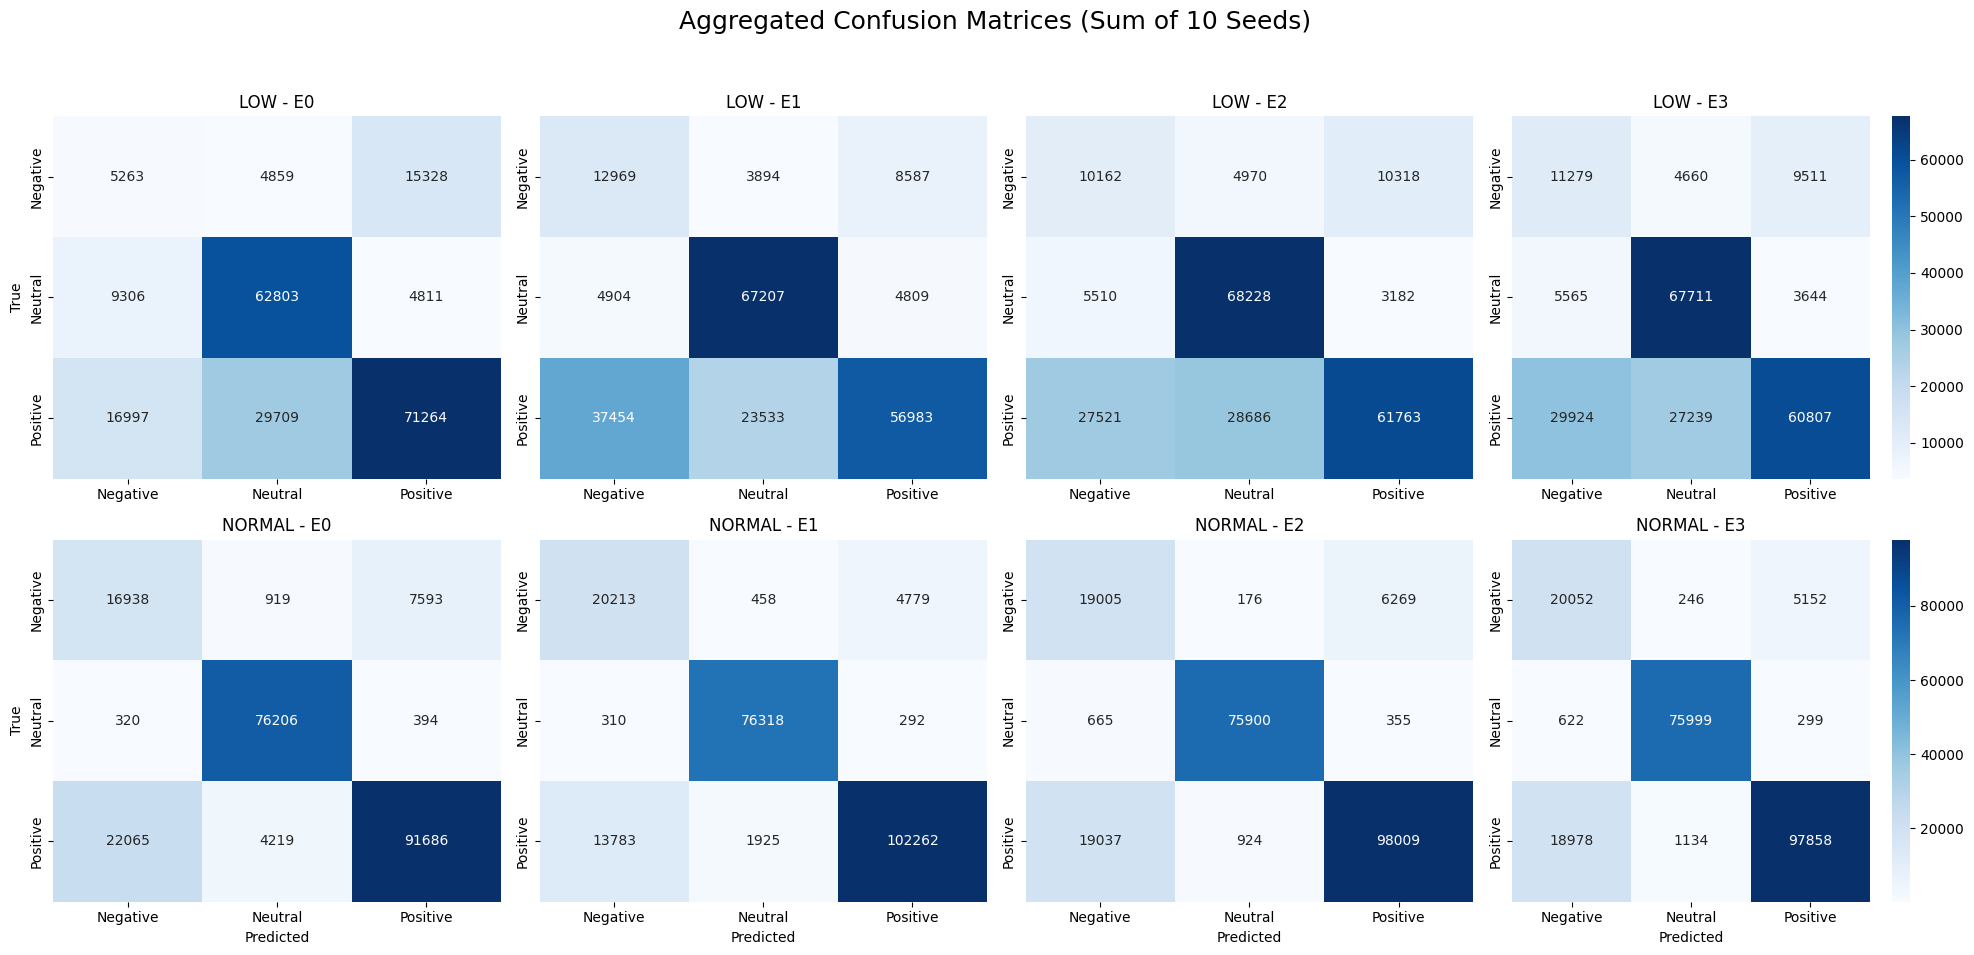

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Aggregated Confusion Matrices (Sum of 10 Seeds)', fontsize=18)
classes = ['Negative', 'Neutral', 'Positive']

for i, level in enumerate(levels):
    for j, scen in enumerate(scenarios):
        ax = axes[i, j]
        key = (level, scen)
        if key in matrix_dict:
            cm = matrix_dict[key]
            cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

            sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', ax=ax,
                        xticklabels=classes, yticklabels=classes,
                        cbar=(j==3))
            ax.set_title(f"{level.upper()} - {scen}")
            if i == 1: ax.set_xlabel('Predicted')
            if j == 0: ax.set_ylabel('True')
        else:
            ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(os.path.join(EVAL_DIR, 'aggregated_confusion_matrices.png'), dpi=300)
plt.show()
